In [1]:
# Author: Remi Flamary <remi.flamary@polytechnique.edu>
#
# License: MIT License

# sphinx_gallery_thumbnail_number = 3

import numpy as np
import matplotlib.pyplot as pl
import matplotlib.animation as animation
import torch
import ot
from torch import nn

### Data generation

In [2]:
torch.manual_seed(1)
sigma = 0.1
n_dims = 2
n_features = 2


def get_data(n_samples):
    c = torch.rand(size=(n_samples, 1))
    angle = c * 2 * np.pi
    x = torch.cat((torch.cos(angle), torch.sin(angle)), 1)
    x += torch.randn(n_samples, 2) * sigma
    return x

### Plot data

<>:4: SyntaxWarning: invalid escape sequence '\m'
<>:4: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_3574865/1598699097.py:4: SyntaxWarning: invalid escape sequence '\m'
  pl.scatter(x[:, 0], x[:, 1], label="Data samples from $\mu_d$", alpha=0.5)


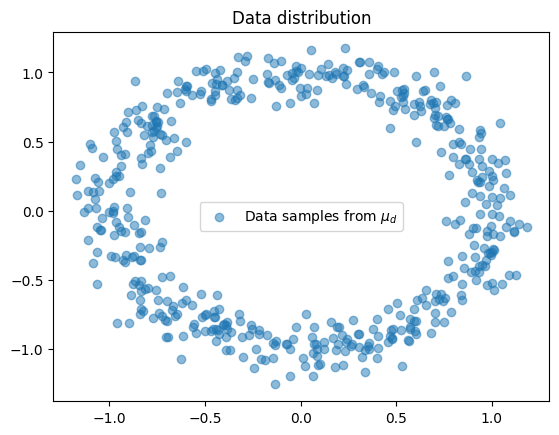

In [3]:
# plot the distributions
x = get_data(500)
pl.figure(1)
pl.scatter(x[:, 0], x[:, 1], label="Data samples from $\mu_d$", alpha=0.5)
pl.title("Data distribution")
pl.legend()

### Generator Model

In [4]:
# define the MLP model
class Generator(torch.nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.fc1 = nn.Linear(n_features, 200)
        self.fc2 = nn.Linear(200, 500)
        self.fc3 = nn.Linear(500, n_dims)
        self.relu = torch.nn.ReLU()  # instead of Heaviside step fn

    def forward(self, x):
        output = self.fc1(x)
        output = self.relu(output)  # instead of Heaviside step fn
        output = self.fc2(output)
        output = self.relu(output)
        output = self.fc3(output)
        return output

### Training the model

Iter:   0, loss=0.9009847640991211
Iter:  10, loss=0.10964284837245941
Iter:  20, loss=0.04564394801855087
Iter:  30, loss=0.03516071289777756
Iter:  40, loss=0.05013977363705635
Iter:  50, loss=0.058588504791259766
Iter:  60, loss=0.03730057179927826
Iter:  70, loss=0.04171676188707352
Iter:  80, loss=0.03168988972902298
Iter:  90, loss=0.031197285279631615
Iter: 100, loss=0.03596879169344902
Iter: 110, loss=0.03272819146513939
Iter: 120, loss=0.032379165291786194
Iter: 130, loss=0.03959248960018158
Iter: 140, loss=0.029337508603930473
Iter: 150, loss=0.05796702206134796
Iter: 160, loss=0.034939464181661606
Iter: 170, loss=0.022607704624533653
Iter: 180, loss=0.04347885772585869
Iter: 190, loss=0.11641815304756165


Text(0.5, 0, 'Iterations')

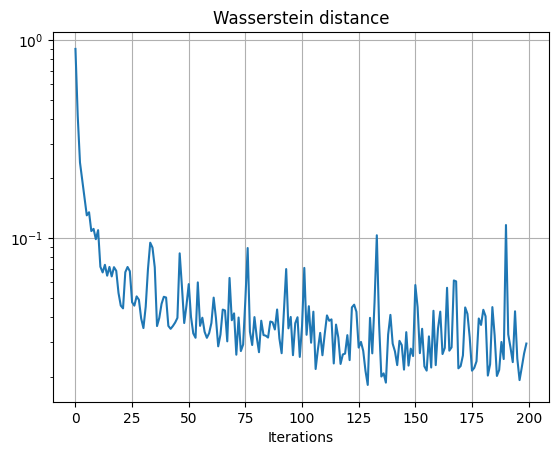

In [5]:
G = Generator()
optimizer = torch.optim.RMSprop(G.parameters(), lr=0.00019, eps=1e-5)

# number of iteration and size of the batches
n_iter = 200  # set to 200 for doc build but 1000 is better ;)
size_batch = 500

# generate statis samples to see their trajectory along training
n_visu = 100
xnvisu = torch.randn(n_visu, n_features)
xvisu = torch.zeros(n_iter, n_visu, n_dims)

ab = torch.ones(size_batch) / size_batch
losses = []


for i in range(n_iter):
    # generate noise samples
    xn = torch.randn(size_batch, n_features)

    # generate data samples
    xd = get_data(size_batch)

    # generate sample along iterations
    xvisu[i, :, :] = G(xnvisu).detach()

    # generate samples and compte distance matrix
    xg = G(xn)
    M = ot.dist(xg, xd)

    loss = ot.emd2(ab, ab, M)
    losses.append(float(loss.detach()))

    if i % 10 == 0:
        print("Iter: {:3d}, loss={}".format(i, losses[-1]))

    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

    del M

pl.figure(2)
pl.semilogy(losses)
pl.grid()
pl.title("Wasserstein distance")
pl.xlabel("Iterations")

### Plot trajectories of generated samples along iterations

<>:7: SyntaxWarning: invalid escape sequence '\m'
<>:11: SyntaxWarning: invalid escape sequence '\#'
<>:7: SyntaxWarning: invalid escape sequence '\m'
<>:11: SyntaxWarning: invalid escape sequence '\#'
/tmp/ipykernel_3574865/3303289528.py:7: SyntaxWarning: invalid escape sequence '\m'
  pl.scatter(xd[:, 0], xd[:, 1], label="Data samples from $\mu_d$", alpha=0.1)
/tmp/ipykernel_3574865/3303289528.py:11: SyntaxWarning: invalid escape sequence '\#'
  label="Data samples from $G\#\mu_n$",


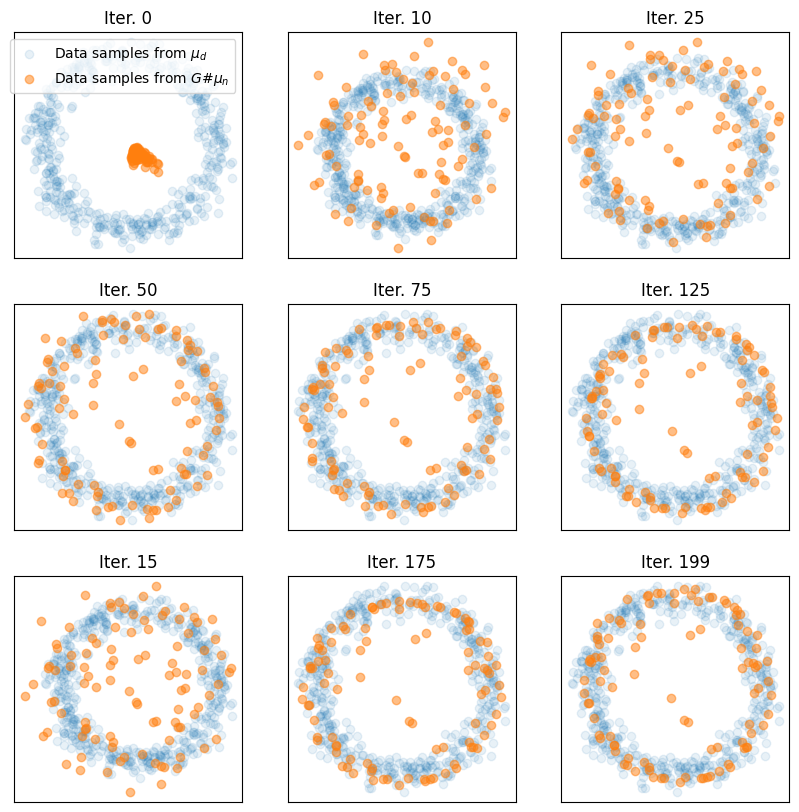

In [6]:
pl.figure(3, (10, 10))

ivisu = [0, 10, 25, 50, 75, 125, 15, 175, 199]

for i in range(9):
    pl.subplot(3, 3, i + 1)
    pl.scatter(xd[:, 0], xd[:, 1], label="Data samples from $\mu_d$", alpha=0.1)
    pl.scatter(
        xvisu[ivisu[i], :, 0],
        xvisu[ivisu[i], :, 1],
        label="Data samples from $G\#\mu_n$",
        alpha=0.5,
    )
    pl.xticks(())
    pl.yticks(())
    pl.title("Iter. {}".format(ivisu[i]))
    if i == 0:
        pl.legend()

### Animate trajectories of generated samples along iteration

<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:8: SyntaxWarning: invalid escape sequence '\#'
<>:19: SyntaxWarning: invalid escape sequence '\m'
<>:21: SyntaxWarning: invalid escape sequence '\#'
<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:8: SyntaxWarning: invalid escape sequence '\#'
<>:19: SyntaxWarning: invalid escape sequence '\m'
<>:21: SyntaxWarning: invalid escape sequence '\#'
/tmp/ipykernel_3574865/3042335700.py:6: SyntaxWarning: invalid escape sequence '\m'
  pl.scatter(xd[:, 0], xd[:, 1], label="Data samples from $\mu_d$", alpha=0.1)
/tmp/ipykernel_3574865/3042335700.py:8: SyntaxWarning: invalid escape sequence '\#'
  xvisu[i, :, 0], xvisu[i, :, 1], label="Data samples from $G\#\mu_n$", alpha=0.5
/tmp/ipykernel_3574865/3042335700.py:19: SyntaxWarning: invalid escape sequence '\m'
  pl.scatter(xd[:, 0], xd[:, 1], label="Data samples from $\mu_d$", alpha=0.1)
/tmp/ipykernel_3574865/3042335700.py:21: SyntaxWarning: invalid escape sequence '\#'
  xvisu[i, :, 0], 

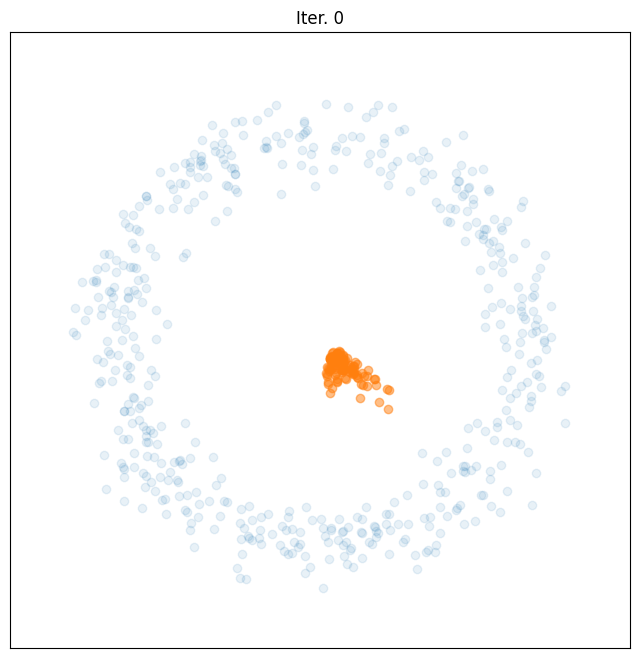

In [7]:
pl.figure(4, (8, 8))


def _update_plot(i):
    pl.clf()
    pl.scatter(xd[:, 0], xd[:, 1], label="Data samples from $\mu_d$", alpha=0.1)
    pl.scatter(
        xvisu[i, :, 0], xvisu[i, :, 1], label="Data samples from $G\#\mu_n$", alpha=0.5
    )
    pl.xticks(())
    pl.yticks(())
    pl.xlim((-1.5, 1.5))
    pl.ylim((-1.5, 1.5))
    pl.title("Iter. {}".format(i))
    return 1


i = 0
pl.scatter(xd[:, 0], xd[:, 1], label="Data samples from $\mu_d$", alpha=0.1)
pl.scatter(
    xvisu[i, :, 0], xvisu[i, :, 1], label="Data samples from $G\#\mu_n$", alpha=0.5
)
pl.xticks(())
pl.yticks(())
pl.xlim((-1.5, 1.5))
pl.ylim((-1.5, 1.5))
pl.title("Iter. {}".format(ivisu[i]))


ani = animation.FuncAnimation(
    pl.gcf(), _update_plot, n_iter, interval=100, repeat_delay=2000
)

### Generate and visualize data

<>:7: SyntaxWarning: invalid escape sequence '\m'
<>:8: SyntaxWarning: invalid escape sequence '\#'
<>:7: SyntaxWarning: invalid escape sequence '\m'
<>:8: SyntaxWarning: invalid escape sequence '\#'
/tmp/ipykernel_3574865/4217526274.py:7: SyntaxWarning: invalid escape sequence '\m'
  pl.scatter(xd[:, 0], xd[:, 1], label="Data samples from $\mu_d$", alpha=0.5)
/tmp/ipykernel_3574865/4217526274.py:8: SyntaxWarning: invalid escape sequence '\#'
  pl.scatter(x[:, 0], x[:, 1], label="Data samples from $G\#\mu_n$", alpha=0.5)


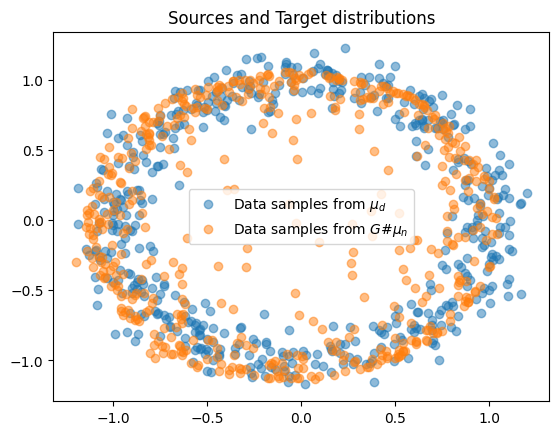

In [8]:
size_batch = 500
xd = get_data(size_batch)
xn = torch.randn(size_batch, 2)
x = G(xn).detach().numpy()

pl.figure(5)
pl.scatter(xd[:, 0], xd[:, 1], label="Data samples from $\mu_d$", alpha=0.5)
pl.scatter(x[:, 0], x[:, 1], label="Data samples from $G\#\mu_n$", alpha=0.5)
pl.title("Sources and Target distributions")
pl.legend()